In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos) ; print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
block_size = 3
def build_dataset(words):
    X,Y = [], []
    for w in words:
        context = [0] * block_size
        #print(w)
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context) , '--->', itos[ix])
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y
# -- SEPERATING DATASETS  --
import random
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [6]:
# INITIALISATION BLOCK (FIXED (removed a bunch of magic numbers hardcoded))
n_emb = 10 # dimensionality of character embedding vectors
n_hidden = 200  # no of neurons in the hidden layer
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size , n_emb),               generator = g)
W1 = torch.randn((n_emb * block_size, n_hidden),    generator = g) * ((5/3)/ (n_emb * block_size)**0.5)
B1 = torch.randn((n_hidden),                        generator = g) * 0.01
W2 = torch.randn((n_hidden,vocab_size),             generator = g) * 0.01
B2 = torch.randn((vocab_size),                      generator = g) * 0

bngain = torch.ones(1, n_hidden)
bnbias = torch.zeros(1, n_hidden)

parameters = [C , W1, B1, W2, B2, bngain, bnbias]
for p in parameters:
    p.requires_grad = True

In [7]:
max_steps = 200000
batch_size = 32
lossi = []
for i in range(max_steps):

    #---MINIBATCHING---
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb , Yb = Xtr[ix] , Ytr[ix]

    #---FORWARD PASS---
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + B1
    hpreact = bngain * (hpreact - hpreact.mean(0,keepdim = True)) / hpreact.std(0,keepdim = True) + bnbias #batch normalisation
    h = torch.tanh(hpreact)
    logits = h @ W2 + B2
    loss = F.cross_entropy(logits,Yb)

    #---BACKWARD PASS---
    for p in parameters:
        p.grad = None
    loss.backward()


    #---UPDATING---
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    #---TRACKING STATS--- 
    if i % 10000 == 0:
        print(f'{i:7d} / {max_steps:7d} {loss.item(): .4f}')
    lossi.append(loss.log10().item())

      0 /  200000  3.3188
  10000 /  200000  2.4664
  20000 /  200000  2.6213
  30000 /  200000  2.3311
  40000 /  200000  2.3246
  50000 /  200000  2.5041
  60000 /  200000  2.2183
  70000 /  200000  2.2618
  80000 /  200000  2.2379
  90000 /  200000  2.1085
 100000 /  200000  2.4663
 110000 /  200000  2.4723
 120000 /  200000  2.0484
 130000 /  200000  1.9066
 140000 /  200000  2.2836
 150000 /  200000  2.0755
 160000 /  200000  2.0607
 170000 /  200000  2.7108
 180000 /  200000  2.0080
 190000 /  200000  2.0268


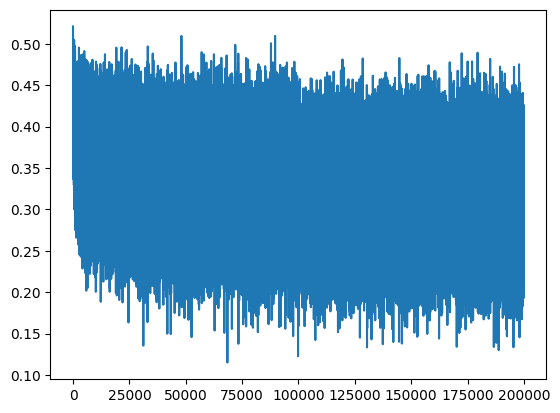

In [8]:
plt.plot(lossi)

In [9]:
@torch.no_grad
def split_making(split):
    x,y = {'train' : (Xtr, Ytr),
           'val' : (Xdev , Ydev),
           'test' : (Xte ,Yte )} [split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + B1
    hpreact = bngain * (hpreact - hpreact.mean(0,keepdim = True)) / hpreact.std(0,keepdim = True) + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + B2
    loss = F.cross_entropy(logits,y)
    print(split , loss.item())

split_making('train')
split_making('val')

train 2.066270112991333
val 2.1097140312194824


In [ ]:
'''
AFTER BATCH NORMALISATION
train 2.066270112991333
val 2.1097140312194824'''

'train 2.1191792488098145\nval 2.168405294418335\n\nAFTER USING 0.2\ntrain 2.0473005771636963\nval 2.113013982772827\n\nAFTER USING GAIN/FAN_IN\ntrain 2.0371930599212646\nval 2.1094970703125\n\nAFTER BATCH NORMALISATION\ntrain 2.0699901580810547\nval 2.1175599098205566'